In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("ryanbadai/clothes-dataset")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 1.37G/1.37G [01:08<00:00, 21.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions/1
Contents of base_path (/root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions):
['1']
Contents of path (/root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions/1):
['Clothes_Dataset']


In [ ]:
import os

# Explore the structure inside 'Clothes_Dataset'
clothes_path = os.path.join(path, 'Clothes_Dataset')
if os.path.exists(clothes_path):
    print(f"Subdirectories in Clothes_Dataset: {os.listdir(clothes_path)}")
else:
    print(f"Directory {clothes_path} does not exist. Please check the file structure.")

Subdirectories in Clothes_Dataset: ['Celana_Panjang', 'Gaun', 'Jaket_Denim', 'Celana_Pendek', 'Rok', 'Blazer', 'Jaket_Olahraga', 'Kaos', 'Polo', 'Hoodie', 'Jeans', 'Sweter', 'Mantel', 'Kemeja', 'Jaket']


Found 7500 images. Displaying 6 sample images:


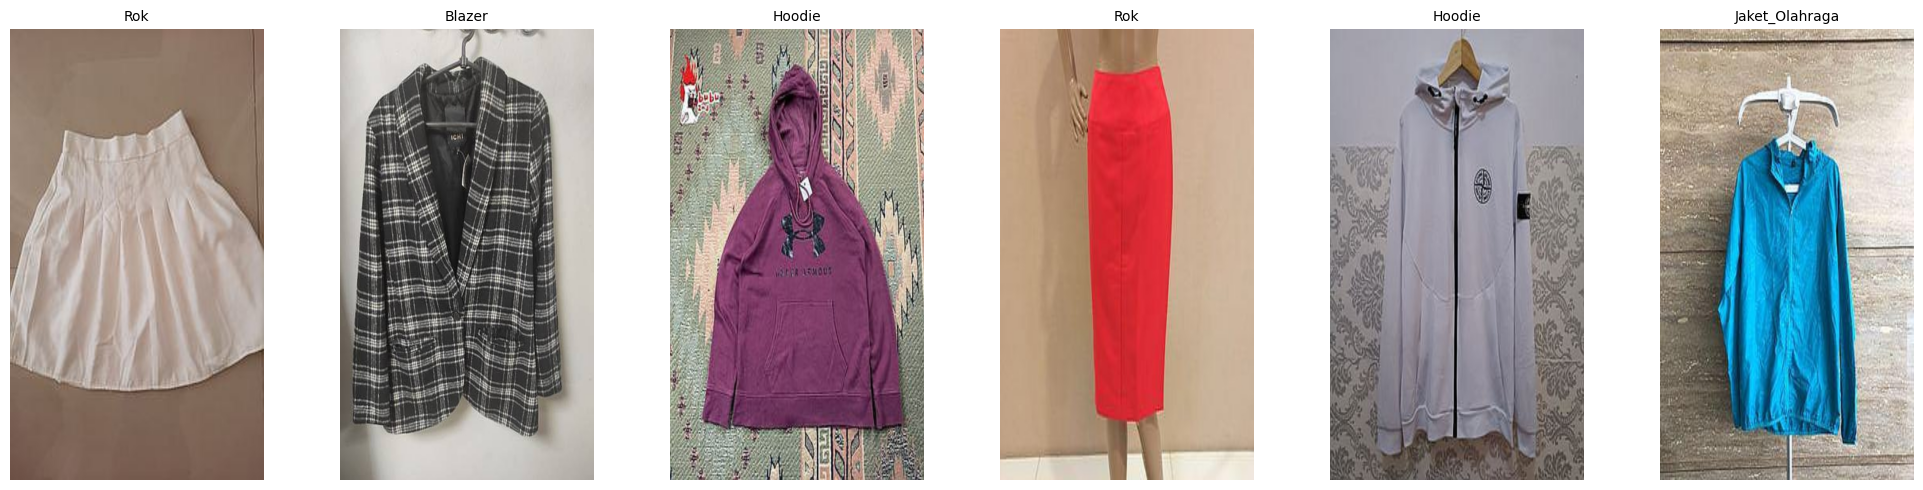

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images. Displaying {min(num_samples, len(all_image_paths))} sample images:")

    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1: axes = [axes]

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(label, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Use the actual path of the clothes dataset
clothes_path = os.path.join(path, 'Clothes_Dataset')
display_sample_images(clothes_path)

In [ ]:
import os

# Define paths for the clothes dataset
input_folder = os.path.join(path, 'Clothes_Dataset')
output_folder = '/content/clothes_dataset_split'

if os.path.exists(input_folder):
    print(f"Preparing to split clothes data from: {input_folder}")
else:
    print(f"Error: {input_folder} not found.")

Preparing to split clothes data from: /root/.cache/kagglehub/datasets/ryanbadai/clothes-dataset/versions/1/Clothes_Dataset


In [ ]:
!pip install split-folders

In [ ]:
import os
try:
    import splitfolders
except ImportError:
    !pip install split-folders
    import splitfolders

# Split the clothes dataset: train=0.8, val(test)=0.2
# seed=42 for reproducibility
if os.path.exists(input_folder):
    splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .2), group_prefix=None, move=False)
    print(f"Clothes dataset split successfully into: {output_folder}")

Copying files: 7500 files [00:08, 902.42 files/s]

Clothes dataset split successfully into: /content/clothes_dataset_split


In [ ]:
# Check the directory structure of the split clothes dataset
for root, dirs, files in os.walk(output_folder):
    level = root.replace(output_folder, '').count(os.sep)
    indent = ' ' * 4 * (level)
    if level <= 1: # Showing top level folders (train/val)
        print(f"{indent}{os.path.basename(root)}/")

In [ ]:
import os

def count_files(directory):
    if not os.path.exists(directory):
        return 0
    return sum([len(files) for r, d, files in os.walk(directory)])

train_count = count_files(os.path.join(output_folder, 'train'))
test_count = count_files(os.path.join(output_folder, 'val'))
total = train_count + test_count

print(f"Clothes Dataset Statistics:")
if total > 0:
    print(f"- Train Set: {train_count} images ({train_count/total*100:.1f}%) -- Target: 80%")
    print(f"- Test Set (val): {test_count} images ({test_count/total*100:.1f}%) -- Target: 20%")
    print(f"- Total images: {total}")
else:
    print("No images found. Please ensure the split command in the previous cell executed successfully.")

Clothes Dataset Statistics:
- Train Set: 6000 images (80.0%) -- Target: 80%
- Test Set (val): 1500 images (20.0%) -- Target: 20%
- Total images: 7500


In [ ]:
import tensorflow as tf

# Check for GPU availability
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found. Please enable GPU in Colab settings (Runtime > Change runtime type).')
else:
    print(f'Found GPU at: {device_name}')
    !nvidia-smi -L

Found GPU at: /device:GPU:0
GPU 0: Tesla T4 (UUID: GPU-7dc8c516-e04f-a86a-844f-784ff4e06fd6)


In [ ]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers

# Data Preparation
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(output_folder, 'train'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    os.path.join(output_folder, 'val'),
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Build MobileNet Model
with tf.device('/GPU:0'):
    base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze base layers

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(train_generator.num_classes, activation='softmax')
    ])

    model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='categorical_loss' if train_generator.num_classes == 2 else 'categorical_crossentropy',
                  metrics=['accuracy'])

# Start Training
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator
)

Found 6000 images belonging to 15 classes.
Found 1500 images belonging to 15 classes.
17225924/17225924 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 155s 745ms/step - accuracy: 0.3818 - loss: 1.9290 - val_accuracy: 0.6213 - val_loss: 1.1573
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 111s 593ms/step - accuracy: 0.5642 - loss: 1.3286 - val_accuracy: 0.6880 - val_loss: 0.9560
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 111s 591ms/step - accuracy: 0.6135 - loss: 1.1713 - val_accuracy: 0.7060 - val_loss: 0.9030
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 112s 595ms/step - accuracy: 0.6515 - loss: 1.0578 - val_accuracy: 0.7227 - val_loss: 0.8331
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 111s 592ms/step - accuracy: 0.6760 - loss: 0.9917 - val_accuracy: 0.7273 - val_loss: 0.8140
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 107s 572ms/step - accuracy: 0.6833 - loss: 0.9539 - val_accuracy: 0.7267 - val_loss: 0.8135
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 112s 595ms/step - accuracy: 0.6

In [ ]:
# Summarize training results
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print("--- Training Summary ---")
print(f"Final Training Accuracy:   {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss:       {final_train_loss:.4f}")
print(f"Final Validation Loss:     {final_val_loss:.4f}")

--- Training Summary ---
Final Training Accuracy:   0.7317
Final Validation Accuracy: 0.7387
Final Training Loss:       0.8039
Final Validation Loss:     0.8063


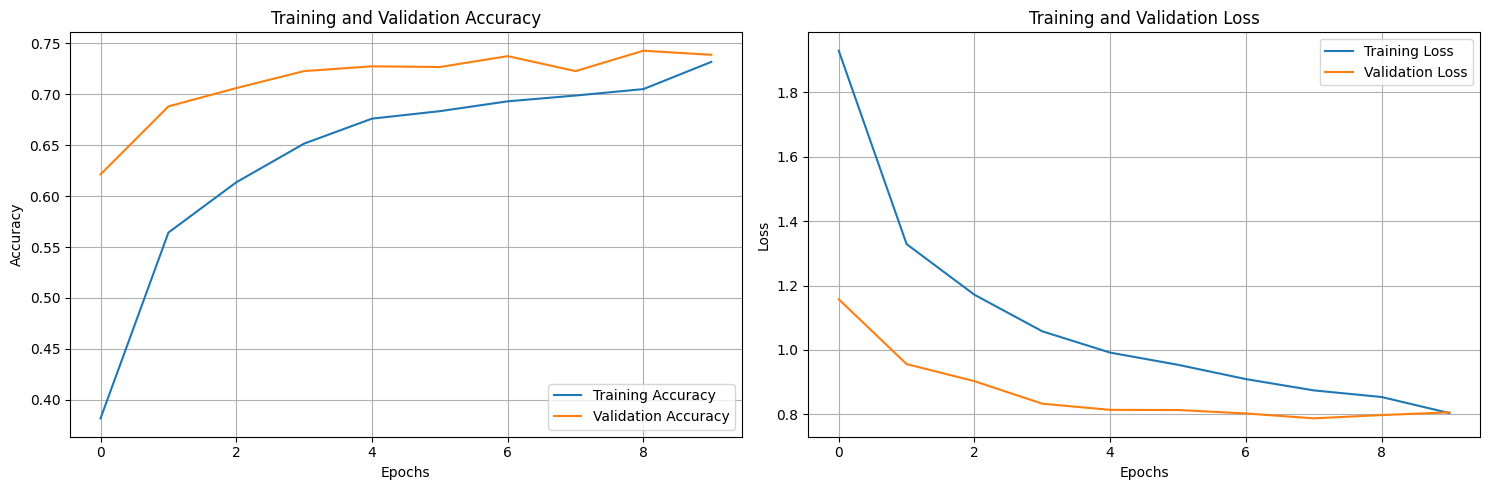

In [ ]:
import matplotlib.pyplot as plt

# Visualize training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()